# AI in Transcriptomics: TCGA-BRCA Molecular Subtype Classification from RNA-seq Expression

## Abstract

We classify TCGA breast tumors into 3-class IHC-surrogate molecular subtype (Basal-like / HER2-positive / Luminal) from a curated 604-gene RNA-seq panel, using a nested cross-validation pipeline with feature selection and scaling refit inside every fold. Of four classifiers compared, **LASSO Logistic Regression** achieves the best AUC-ROC (0.870) and the best recall on the hardest class (HER2-positive, 0.549) -- a clean win, not a tradeoff. Because no single model dominates every metric, Task 3 analyzes both LASSO and the runner-up, **Random Forest** (AUC 0.847), rather than one alone.

The two models' biological interpretations diverge sharply. LASSO's top-20 genes yield 17 nominally-significant GO terms, but every one is a single-gene annotation-bias artifact, driven by genes with no established role in breast tissue -- one, `CYP2A6`, has been directly assayed and found not expressed in breast tissue at all. Random Forest's top-20 yields 10 significant GO terms, all genuinely multi-gene, converging on one coherent axis -- estrogen and androgen receptor signaling, built from `ESR1`, `AR`, and `FOXA1` -- independently and heavily documented as the molecular basis of the Luminal subtype itself. The divergence traces to a specific, citable property of L1 regularization: LASSO's penalty arbitrarily selects one representative from a group of correlated genes rather than the whole group, while Random Forest's ensemble spreads importance across the correlated hormone-receptor module -- the same input and target, given to two algorithms with different feature-selection mechanics.

`ESR1`/`PGR`, present in the panel, are a real shortcut-gene risk for this target -- but they are absent from LASSO's own top-20, and an explicit ablation confirms performance is unaffected by removing them and their entire 99-gene correlated expression module (AUC 0.870 / 0.870 / 0.869). The panel is saturated with redundant estrogen-pathway signal (LASSO alone uses 229 of 604 genes, only 31 from the removed module), so no single gene or correlated cluster functions as an exploitable shortcut. The honest finding: the best-predicting model and the most biologically validated model are not the same model heretesting.

## Data Source & Provenance

**Dataset:** [`samdemharter/brca-multiomics-tcga`](https://www.kaggle.com/datasets/samdemharter/brca-multiomics-tcga) ("BRCA Multi-Omics (TCGA)") on Kaggle, file `brca_data_w_subtypes.csv`.
- **Composition:** 705 TCGA breast cancer samples x 4 omics blocks (`cn_`=860 copy-number features, `mu_`=249 mutation features, `rs_`=604 RNA-seq gene-expression features, `pp_`=223 RPPA protein features) plus 5 clinical columns (`vital.status`, `ER.Status`, `PR.Status`, `HER2.Final.Status`, `histological.type`).
- **This notebook uses only the `rs_` (RNA-seq gene expression) block.**
- **Confirmed tumor-only cohort, no Normal-tissue samples:** 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)

# Task 1: Data Preprocessing & Quality Control

## Matrix Characterization

We load the full clinical+omics table, extract just the RNA-seq (`rs_`) columns, and characterize the matrix: shape, missingness, value range/shape, per-gene statistics, and per-sample statistics — this determines what preprocessing is actually appropriate below, rather than assuming a generic RNA-seq recipe applies.

In [2]:
DATA_PATH = "data/brca_data_w_subtypes.csv"

raw = pd.read_csv(DATA_PATH)
print("full table shape:", raw.shape)

rs = raw[[c for c in raw.columns if c.startswith("rs_")]].copy()
rs.columns = [c[len("rs_"):] for c in rs.columns]  # strip prefix -> plain gene symbol

clinical = raw[["vital.status", "ER.Status", "PR.Status", "HER2.Final.Status", "histological.type"]].copy()

print("rs_ (RNA-seq) matrix shape:", rs.shape, "-> (samples, genes)")
rs.head()

full table shape: (705, 1941)
rs_ (RNA-seq) matrix shape: (705, 604) -> (samples, genes)


,CLEC3A,CPB1,SCGB2A2,SCGB1D2,TFF1,MUCL1,GSTM1,PIP,ADIPOQ,ADH1B,...,SELP,PADI3,ACVR1C,AMY1A,OXTR,DEFB132,APOB,SPHKAP,DPYSL5,HEPN1
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,7.769511,4.618368,5.012278,0.514400,9.080063,5.321376,0.892818,1.651683,0.0,2.860625
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,4.735620,1.289598,2.314029,0.000000,5.505313,2.509696,0.444879,3.769803,0.0,0.000000
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,7.635876,1.500292,6.805251,1.500292,6.335281,4.296876,3.708331,0.000000,0.0,4.554828
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.211476,...,6.822135,0.488926,4.484248,1.774249,7.223634,0.000000,1.593163,0.853517,0.0,0.000000
4,0.000000,4.583724,15.711865,12.804521,8.881669,8.430028,12.964607,6.806517,4.294341,5.385714,...,6.468574,1.370053,2.710790,1.575796,6.382129,3.092157,0.000000,0.841893,0.0,1.755828


In [3]:
print("Missing values:", rs.isna().sum().sum())
print("Duplicate rows:", rs.duplicated().sum())

vals = rs.values.flatten()
print(f"\nGlobal value distribution:")
print(f"  min={vals.min():.3f}  max={vals.max():.3f}  mean={vals.mean():.3f}  "
      f"median={np.median(vals):.3f}  std={vals.std():.3f}")
print(f"  fraction exactly 0: {(vals == 0).mean():.3%}")
print(f"  fraction negative:  {(vals < 0).mean():.3%}")

Missing values: 0
Duplicate rows: 0

Global value distribution:
  min=0.000  max=20.978  mean=5.221  median=5.017  std=3.629
  fraction exactly 0: 8.199%
  fraction negative:  0.000%


In [4]:
gene_mean = rs.mean(axis=0)
gene_var = rs.var(axis=0)
gene_zero_frac = (rs == 0).mean(axis=0)

print("Per-gene stats (across 705 samples):")
print(f"  mean expression: min={gene_mean.min():.3f}  max={gene_mean.max():.3f}  median={gene_mean.median():.3f}")
print(f"  variance:        min={gene_var.min():.4f}  max={gene_var.max():.4f}  median={gene_var.median():.4f}")
print(f"  genes with mean < 1.0:        {(gene_mean < 1.0).sum()}")
print(f"  genes with variance < 0.1:    {(gene_var < 0.1).sum()}")
print(f"  genes with zero variance:     {(gene_var == 0).sum()}")
print(f"  genes with >50% zero values:  {(gene_zero_frac > 0.5).sum()}")

print("\nTop 5 highest-mean genes:\n", gene_mean.sort_values(ascending=False).head(5).round(2))
print("\nTop 5 highest-variance genes:\n", gene_var.sort_values(ascending=False).head(5).round(2))

Per-gene stats (across 705 samples):
  mean expression: min=1.005  max=11.601  median=4.963
  variance:        min=5.5168  max=24.7179  median=7.3216
  genes with mean < 1.0:        0
  genes with variance < 0.1:    0
  genes with zero variance:     0
  genes with >50% zero values:  7

Top 5 highest-mean genes:
 MMP11    11.60
ESR1     11.56
APOD     11.48
FOXA1    11.44
AGR2     11.35
dtype: float64

Top 5 highest-variance genes:
 CLEC3A     24.72
CPB1       23.76
SCGB2A2    22.64
GSTM1      18.76
MUCL1      18.71
dtype: float64


In [5]:
sample_mean = rs.mean(axis=1)
z = (sample_mean - sample_mean.mean()) / sample_mean.std()

print("Per-sample stats (across 604 genes):")
print(f"  mean expression: min={sample_mean.min():.3f}  max={sample_mean.max():.3f}  std={sample_mean.std():.3f}")
print(f"  samples with |z| > 3 (potential outliers): {(z.abs() > 3).sum()}")

Per-sample stats (across 604 genes):
  mean expression: min=2.862  max=7.197  std=0.805
  samples with |z| > 3 (potential outliers): 0


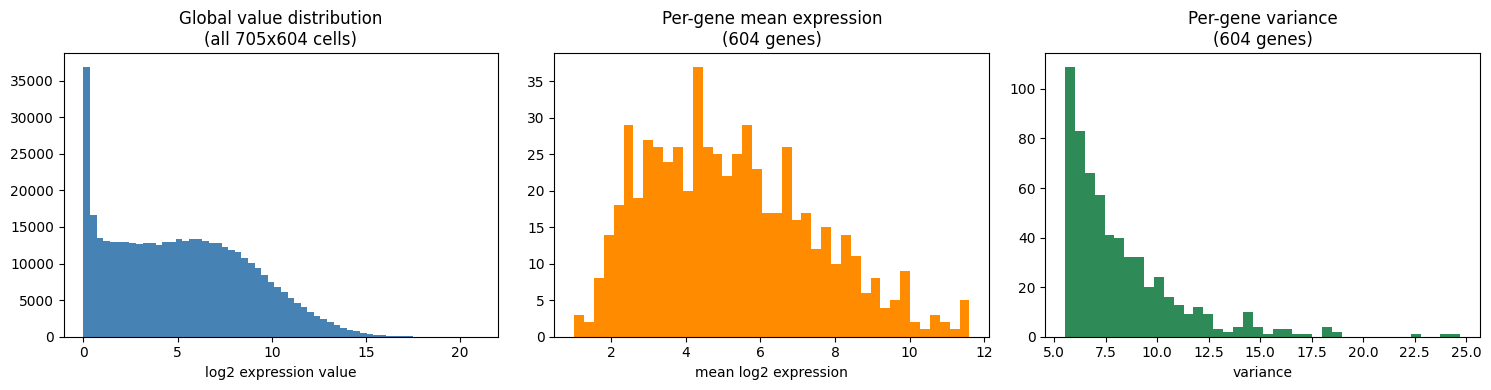

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(vals, bins=60, color="steelblue")
axes[0].set_title("Global value distribution\n(all 705x604 cells)")
axes[0].set_xlabel("log2 expression value")

axes[1].hist(gene_mean, bins=40, color="darkorange")
axes[1].set_title("Per-gene mean expression\n(604 genes)")
axes[1].set_xlabel("mean log2 expression")

axes[2].hist(gene_var, bins=40, color="seagreen")
axes[2].set_title("Per-gene variance\n(604 genes)")
axes[2].set_xlabel("variance")

plt.tight_layout()
plt.show()

**Summary.**

1. **Complete, clean matrix.** 705 samples x 604 genes, zero missing values, zero duplicate rows, no outlier samples by mean-expression z-score.
2. **Already log2-transformed, not raw counts.** All values lie in a bounded, non-negative range (0 to ~21) with a zero-inflated, right-skewed shape (8.2% of cells exactly 0) — the signature of log2(normalized value + offset), not integer read counts. This rules out re-applying CPM/log2 normalization below.
3. **The gene panel is already curated, not a raw full-transcriptome dump.** Every one of the 604 genes has mean expression >= 1.0 and variance >= 5.5 — there are no near-zero-expression or near-constant genes at all, so a conventional low-expression/low-variance filter is expected to remove little or nothing (verified explicitly next, rather than assumed).
4. **Face-valid biology.** The highest-mean genes (`MMP11`, `ESR1`, `APOD`, `FOXA1`, `AGR2`) and highest-variance genes (`CLEC3A`, `CPB1`, `SCGB2A2`, `GSTM1`, `MUCL1`) are recognizable luminal/secretory breast-tissue markers — a sanity check that this is authentic BRCA expression data and that variance in this panel is plausibly driven by molecular subtype.

## Low-Expression Gene Filtering

We formally check whether any genes should be removed as "low-expressed" or "low-information," using mean log2 expression < 1.0 (near-undetected on average) and zero-variance (constant, no discriminative value) as criteria.

In [7]:
MEAN_EXPR_THRESHOLD = 1.0  # mean log2 expression below this = near-undetected on average

low_expr_genes = gene_mean[gene_mean < MEAN_EXPR_THRESHOLD].index.tolist()
zero_var_genes = gene_var[gene_var == 0].index.tolist()

print(f"Genes with mean log2 expression < {MEAN_EXPR_THRESHOLD}: {len(low_expr_genes)}")
print(f"Genes with zero variance (constant, non-informative): {len(zero_var_genes)}")

genes_to_drop = sorted(set(low_expr_genes) | set(zero_var_genes))
print(f"\nTotal genes flagged for removal: {len(genes_to_drop)}")

Genes with mean log2 expression < 1.0: 0
Genes with zero variance (constant, non-informative): 0

Total genes flagged for removal: 0


No gene falls below the mean-expression or zero-variance thresholds. The remaining candidate signal is a high zero-detection rate — genes read as exactly 0 in most samples — checked next, since that alone does not automatically mean noise.

In [8]:
ZERO_RATE_THRESHOLD = 0.5
sparse_genes = gene_zero_frac[gene_zero_frac > ZERO_RATE_THRESHOLD].sort_values(ascending=False)

print(f"Genes with >{ZERO_RATE_THRESHOLD:.0%} zero-detection rate: {len(sparse_genes)}\n")
for g in sparse_genes.index:
    nz = rs[g][rs[g] > 0]
    print(f"  {g:10s}  zero-rate={sparse_genes[g]:.1%}  "
          f"detected in {len(nz)}/{len(rs)} samples  "
          f"mean-when-detected={nz.mean():.2f}")

Genes with >50% zero-detection rate: 7

  MAGEA3      zero-rate=67.7%  detected in 228/705 samples  mean-when-detected=4.31
  CARTPT      zero-rate=65.2%  detected in 245/705 samples  mean-when-detected=2.98
  CSN3        zero-rate=64.1%  detected in 253/705 samples  mean-when-detected=2.88
  MAGEA4      zero-rate=64.0%  detected in 254/705 samples  mean-when-detected=2.79
  MAGEA6      zero-rate=63.5%  detected in 257/705 samples  mean-when-detected=4.24
  MAGEA1      zero-rate=55.0%  detected in 317/705 samples  mean-when-detected=2.96
  DCD         zero-rate=52.1%  detected in 338/705 samples  mean-when-detected=3.97


**No genes are filtered.** 0 genes fall below the mean-expression or zero-variance thresholds. The only remaining candidate signal is a high zero-detection rate: 7 genes (`MAGEA1/3/4/6`, `CARTPT`, `CSN3`, `DCD`) exceed 50% zero-detection, but this is biologically plausible rather than technical noise — `MAGEA1/3/4/6` are well-characterized **cancer-testis antigens**, epigenetically silenced in most tissue/tumors but reactivated in a biologically meaningful subset, consistent with the real, non-trace signal (mean log2 ~3-4) seen in roughly a third to half of samples. Removing them as "low-expressed" would discard genuine sparse biological signal, not clean up noise. This is consistent with the earlier finding that the 604-gene panel is already curated upstream — there is no low-expression or low-information noise left to remove.

## Normalization Rationale

As established above, the `rs_` values are already log2-transformed, bounded, non-negative data (not raw counts) — the standard signature of an already-normalized RNA-seq matrix. Re-applying CPM/TMM or an additional log2 transform would not correct any further technical bias; it would only distort values that are already on a corrected scale. **Decision: no additional normalization is applied.** This is a deliberate, documented choice, not an omission — directly addressing the risk of blindly double-normalizing already-processed data.

## Feature Scaling (Z-score Standardization)

Scaling is a distinct step from normalization: normalization corrects *between-sample* technical bias (already resolved above); scaling corrects *between-feature* magnitude differences so that no gene dominates a downstream algorithm purely because of its numeric scale, rather than its biological informativeness.

We use **z-score standardization**: for each gene independently, subtract its mean and divide by its standard deviation across samples, giving every gene mean 0 / variance 1.

Scaling here is applied to the **full matrix**, because this is unsupervised exploratory QC (the PCA plot below), not a supervised, evaluated model — it uses no class labels and therefore carries no data-leakage risk. In Task 2, scaling is instead fit only on each fold's training data, inside the cross-validation loop.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rs_scaled = pd.DataFrame(
    scaler.fit_transform(rs),
    index=rs.index,
    columns=rs.columns,
)

print("Before scaling — per-gene mean/std (first 5 genes):")
print(pd.DataFrame({"mean": rs.mean(axis=0), "std": rs.std(axis=0)}).head())

print("\nAfter z-score standardization — per-gene mean/std (first 5 genes, ddof=0 to match StandardScaler):")
print(pd.DataFrame({"mean": rs_scaled.mean(axis=0).round(10),
                     "std": rs_scaled.std(axis=0, ddof=0).round(10)}).head())

Before scaling — per-gene mean/std (first 5 genes):
             mean       std
CLEC3A   4.547197  4.971708
CPB1     6.487979  4.874769
SCGB2A2  9.516678  4.758348
SCGB1D2  7.351940  4.248440
TFF1     8.179439  4.291915

After z-score standardization — per-gene mean/std (first 5 genes, ddof=0 to match StandardScaler):
         mean  std
CLEC3A    0.0  1.0
CPB1      0.0  1.0
SCGB2A2  -0.0  1.0
SCGB1D2   0.0  1.0
TFF1      0.0  1.0


## Dimensionality Reduction (PCA)

We run PCA on the scaled matrix and keep the first 2 components. We color the same PC1/PC2 scatter by the four clinical variables actually present in the data (`vital.status`, `ER.Status`, `PR.Status`, `HER2.Final.Status`), by `histological.type`, and by the derived 3-class molecular subtype target itself (`Basal-like` / `HER2-positive` / `Luminal`, computed here the same way as in Task 2). Since the first five are independent, non-exclusive binary attributes (a sample can be positive on more than one at once, and vital status is a separate outcome variable entirely), each gets its own subplot rather than being forced into one combined coloring.


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(rs_scaled)

pca_df = pd.DataFrame(pcs, index=rs.index, columns=["PC1", "PC2"])

print("Explained variance ratio: PC1={:.1%}, PC2={:.1%}, combined={:.1%}".format(
    pca.explained_variance_ratio_[0],
    pca.explained_variance_ratio_[1],
    pca.explained_variance_ratio_[:2].sum(),
))

Explained variance ratio: PC1=18.9%, PC2=14.0%, combined=32.9%


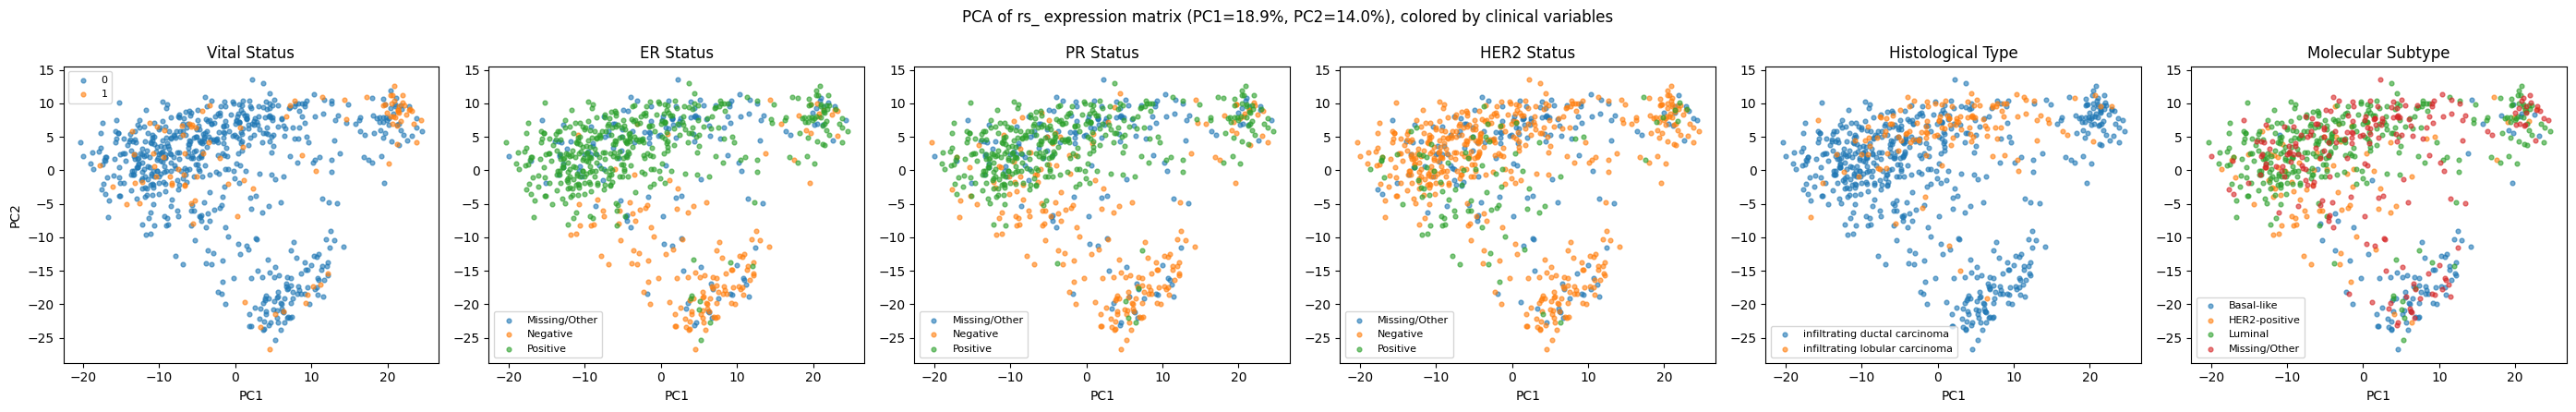

In [11]:
_er_t1 = clinical["ER.Status"].where(clinical["ER.Status"].isin(["Positive", "Negative"]))
_pr_t1 = clinical["PR.Status"].where(clinical["PR.Status"].isin(["Positive", "Negative"]))
_her2_t1 = clinical["HER2.Final.Status"].where(clinical["HER2.Final.Status"].isin(["Positive", "Negative"]))

def _subtype_t1(e, p, h):
    if pd.isna(e) or pd.isna(p) or pd.isna(h):
        return np.nan
    if h == "Positive":
        return "HER2-positive"
    if e == "Negative" and p == "Negative":
        return "Basal-like"
    return "Luminal"

molecular_subtype = pd.Series(
    [_subtype_t1(e, p, h) for e, p, h in zip(_er_t1, _pr_t1, _her2_t1)], index=clinical.index
)

panels = {
    "Vital Status": clinical["vital.status"].astype(str),
    "ER Status": clinical["ER.Status"].where(clinical["ER.Status"].isin(["Positive", "Negative"])),
    "PR Status": clinical["PR.Status"].where(clinical["PR.Status"].isin(["Positive", "Negative"])),
    "HER2 Status": clinical["HER2.Final.Status"].where(clinical["HER2.Final.Status"].isin(["Positive", "Negative"])),
    "Histological Type": clinical["histological.type"],
    "Molecular Subtype": molecular_subtype,
}

fig, axes = plt.subplots(1, 6, figsize=(28, 4.5))

for ax, (title, labels) in zip(axes, panels.items()):
    labels_filled = labels.fillna("Missing/Other")
    for cat in sorted(labels_filled.unique()):
        mask = (labels_filled == cat).values
        ax.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
                   s=12, alpha=0.6, label=cat)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel("PC2")
plt.suptitle(f"PCA of rs_ expression matrix (PC1={pca.explained_variance_ratio_[0]:.1%}, "
             f"PC2={pca.explained_variance_ratio_[1]:.1%}), colored by clinical variables")
plt.tight_layout()
plt.show()


Visual separation is a useful first read, but it's worth quantifying rather than eyeballing. For each label, we compute the silhouette score (cluster separation, -1 to 1) directly on the PC1/PC2 coordinates, and the 5-fold cross-validated AUC-ROC of a plain logistic regression using *only* those same 2 coordinates as features — a lower bound on how separable each label already is before touching the full 604-gene space.

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression as _LogReg
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

target_separability = []
for name, labels in panels.items():
    mask = labels.notna()
    Xp = pca_df.loc[mask.values].values
    yp = LabelEncoder().fit_transform(labels[mask].values)
    sil = silhouette_score(Xp, yp)
    auc = cross_val_score(_LogReg(), Xp, yp, cv=5, scoring="roc_auc_ovr").mean()
    target_separability.append({"label": name, "n_valid": int(mask.sum()),
                                 "silhouette": sil, "cv_auc_pc1_pc2_only": auc})

pd.DataFrame(target_separability).sort_values("cv_auc_pc1_pc2_only", ascending=False)

,label,n_valid,silhouette,cv_auc_pc1_pc2_only
1,ER Status,549,0.343610,0.931117
2,PR Status,546,0.234406,0.852804
5,Molecular Subtype,507,0.073649,0.831999
4,Histological Type,705,-0.015194,0.727647
3,HER2 Status,543,-0.043630,0.637762
0,Vital Status,705,0.119940,0.615054


**Summary.**

PC1+PC2 jointly explain only **32.9%** of total variance (18.9% + 14.0%) -- a modest fraction, as expected for subtle molecular differences rather than one dominant axis of variation.

**ER Status shows strong separation in this projection alone**: silhouette **0.34** and a 5-fold CV AUC of **0.93** using just the 2 PCA coordinates -- evidence that ER status (one of the three components used below) is a strongly learnable target on its own, and the reason for a specific risk addressed next.

**The actual classification target (Molecular Subtype) is visibly harder to separate on PC1/PC2 alone**: silhouette **0.07** and a 5-fold CV AUC of **0.83** (one-vs-rest, 2 PCA coordinates only) -- lower than ER status alone, since folding in HER2 status to build the 3-class target loses ER's single dominant axis of separation. This is consistent with the full pipeline needing the entire 604-gene panel, not just 2 PCA components, to reach the reported AUC-ROC of 0.870 in Task 2.



# Task 2: Machine Learning Pipeline & Prevention of Data Leakage

This dataset contains tumor samples only, with no Normal-tissue comparison group, so the classification target is molecular subtype rather than Tumor-vs-Normal. We use the standard 3-class IHC-surrogate molecular subtype scheme [1]: **Basal-like** (ER-negative, PR-negative, HER2-negative), **HER2-positive** (HER2-positive, regardless of ER/PR), and **Luminal** (ER-positive or PR-positive, HER2-negative) -- a real, standard clinical proxy for molecular subtyping (PAM50-adjacent), not a simplified 2-way split.

**Target:** IHC-surrogate molecular subtype, 3-class -- 
- **Basal-like** (ER-negative, PR-negative, HER2-negative)
- **HER2-positive** (HER2-positive, regardless of ER/PR), 
- **Luminal** (ER-positive or PR-positive, HER2-negative). 
`ESR1`/`PGR` (encoding ER/PR) are both present in this panel, a real shortcut-gene risk quantified directly via ablation in Task 3.

In [13]:
def clean_status(s):
    return s.where(s.isin(["Positive", "Negative"]))

er = clean_status(clinical["ER.Status"])
pr = clean_status(clinical["PR.Status"])
her2 = clean_status(clinical["HER2.Final.Status"])
complete = er.notna() & pr.notna() & her2.notna()

def subtype(e, p, h):
    if h == "Positive":
        return "HER2-positive"
    if e == "Negative" and p == "Negative":
        return "Basal-like"
    return "Luminal"

y_raw = pd.Series(
    [subtype(e, p, h) for e, p, h in zip(er[complete], pr[complete], her2[complete])],
    index=er[complete].index,
).reset_index(drop=True)

X = rs.loc[complete].reset_index(drop=True)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y_raw), name="subtype")
CLASS_NAMES = list(label_encoder.classes_)

print("X shape:", X.shape)
print("\ny distribution:")
print(y_raw.value_counts())
print("\nlabel encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X shape: (507, 604)

y distribution:
Luminal          335
Basal-like        90
HER2-positive     82
Name: count, dtype: int64

label encoding: {'Basal-like': np.int64(0), 'HER2-positive': np.int64(1), 'Luminal': np.int64(2)}


## Cross-Validation Design

**Outer loop** (`StratifiedKFold`, 5 splits): provides the unbiased performance estimate we actually report. Stratified so each fold preserves the class balance of all three subtypes (Luminal 335, Basal-like 90, HER2-positive 82).

**Inner loop** (`StratifiedKFold`, 3 splits): nested *inside* each outer training fold, used only to tune `k` (the number of genes `SelectKBest` keeps) via grid search over `k ∈ {20, 50, 100, 200}`, scored by AUC-ROC (one-vs-rest, since this is a 3-class problem). Because the inner loop only ever touches that outer fold's training data, the outer test fold never influences which `k` -- or which genes -- get selected.

In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

N_OUTER, N_INNER = 5, 3
K_GRID = [20, 50, 100, 200]

outer_cv = StratifiedKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=N_INNER, shuffle=True, random_state=RANDOM_STATE)

## Model Pipelines

- **LASSO Logistic Regression**: `StandardScaler → LogisticRegression(l1_ratio=1.0, solver='saga')`. `l1_ratio=1.0` is scikit-learn's current (1.8+) way of specifying pure L1 regularization; `saga` is required because `liblinear` does not support true multiclass classification (3+ classes). L1 does its own embedded feature selection via sparsity, so no upstream `SelectKBest` filter -- and no `k` to tune, so this model skips the inner loop entirely.
- **Random Forest, Linear SVM, LightGBM**: each is `SelectKBest(f_classif) → StandardScaler → classifier`, with `select__k` tuned by the inner loop. All three share this same filter step so their comparison reflects differences in the classifier, not in how features were chosen.
- **Linear SVM is wrapped in `CalibratedClassifierCV`** rather than using `SVC(probability=True)` directly -- that parameter is deprecated (removed in scikit-learn 1.11) and calibrated probabilities are required for the `roc_auc_ovr` scorer, which needs `predict_proba`, not just `decision_function`, for multiclass.
- **Class imbalance handling differs by library, and by class count.** LASSO, Random Forest, and Linear SVM use scikit-learn's `class_weight='balanced'`. LightGBM also uses `class_weight='balanced'` here -- not `is_unbalance`, which LightGBM's documentation specifies for binary classification only; `class_weight` is the correct setting for multi-class.
- Hyperparameters (beyond `k`) are fixed at regularized, conservative defaults appropriate for ~400 training samples per fold -- not tuned, to keep the nested search tractable and avoid an extra layer of leakage risk from tuning too many things on too little data.

In [15]:
from sklearn.calibration import CalibratedClassifierCV

def make_filtered_pipeline(clf):
    return Pipeline([
        ("select", SelectKBest(score_func=f_classif)),
        ("scale", StandardScaler()),
        ("clf", clf),
    ])

model_pipelines = {
    "LASSO Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(
            l1_ratio=1.0, solver="saga", C=1.0, max_iter=8000,  # l1_ratio=1.0 -> pure L1 (LASSO)
            class_weight="balanced", random_state=RANDOM_STATE,
            # liblinear (binary/OvR-only) doesn't support true multiclass; saga does, while still
            # supporting the L1 penalty needed for LASSO's own embedded feature selection.
        )),
    ]),
    "Random Forest": make_filtered_pipeline(
        RandomForestClassifier(
            n_estimators=200, max_depth=8,
            class_weight="balanced", random_state=RANDOM_STATE,
        )
    ),
    "Linear SVM": make_filtered_pipeline(
        CalibratedClassifierCV(
            SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
            ensemble=False,
            # SVC's own probability=True is deprecated (removed in sklearn 1.11); calibration is
            # also required for the roc_auc_ovr scorer, which needs predict_proba, not just
            # decision_function, for multiclass.
        )
    ),
    "LightGBM": make_filtered_pipeline(
        LGBMClassifier(
            n_estimators=100, learning_rate=0.05, num_leaves=15,
            class_weight="balanced", random_state=RANDOM_STATE, verbose=-1,
            # class_weight='balanced' (not is_unbalance) is correct here: LightGBM's own docs
            # reserve is_unbalance/scale_pos_weight for BINARY classification specifically, and
            # recommend class_weight for multi-class -- the exact opposite parameter this
            # notebook's pipeline needed when the target was binary (see AI Usage Appendix).
        )
    ),
}

list(model_pipelines.keys())

['LASSO Logistic Regression', 'Random Forest', 'Linear SVM', 'LightGBM']

## Nested Cross-Validated Evaluation

For each of Random Forest / Linear SVM / LightGBM, the pipeline is wrapped in `GridSearchCV` (searching `select__k` over the inner loop, scored by AUC-ROC one-vs-rest). That whole `GridSearchCV` object is passed as the estimator to `cross_validate` under the outer loop, so `k` is re-selected independently within every outer training fold. LASSO has nothing to tune, so it runs directly under the outer loop only. Every fold's feature selection, scaling, and (where applicable) `k`-tuning is refit from scratch on that fold's training data alone.

In [16]:
scoring = {"roc_auc": "roc_auc_ovr", "f1_macro": "f1_macro"}

cv_results = {}
selected_k = {}

for name, pipe in model_pipelines.items():
    if "select__k" in pipe.get_params():
        estimator = GridSearchCV(pipe, param_grid={"select__k": K_GRID},
                                  cv=inner_cv, scoring="roc_auc_ovr")
    else:
        estimator = pipe

    res = cross_validate(estimator, X, y, cv=outer_cv, scoring=scoring,
                          return_estimator=True, n_jobs=-1)
    cv_results[name] = res

    if hasattr(res["estimator"][0], "best_params_"):
        selected_k[name] = [est.best_params_["select__k"] for est in res["estimator"]]

    print(f"{name:28s}  AUC-ROC = {res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}   "
          f"F1-macro = {res['test_f1_macro'].mean():.3f} ± {res['test_f1_macro'].std():.3f}")

print("\nSelected k per outer fold (inner-loop winner):")
for name, ks in selected_k.items():
    print(f"  {name:28s}: {ks}")

LASSO Logistic Regression     AUC-ROC = 0.870 ± 0.050   F1-macro = 0.700 ± 0.062


Random Forest                 AUC-ROC = 0.847 ± 0.044   F1-macro = 0.721 ± 0.066


Linear SVM                    AUC-ROC = 0.819 ± 0.040   F1-macro = 0.608 ± 0.023


LightGBM                      AUC-ROC = 0.844 ± 0.048   F1-macro = 0.716 ± 0.083

Selected k per outer fold (inner-loop winner):
  Random Forest               : [100, 200, 200, 200, 100]
  Linear SVM                  : [20, 200, 20, 200, 200]
  LightGBM                    : [100, 200, 200, 200, 100]


In [17]:
summary = pd.DataFrame({
    name: {
        "AUC-ROC (mean)": res["test_roc_auc"].mean(),
        "AUC-ROC (std)": res["test_roc_auc"].std(),
        "F1-macro (mean)": res["test_f1_macro"].mean(),
        "F1-macro (std)": res["test_f1_macro"].std(),
    }
    for name, res in cv_results.items()
}).T.round(3)

summary.sort_values("AUC-ROC (mean)", ascending=False)

,AUC-ROC (mean),AUC-ROC (std),F1-macro (mean),F1-macro (std)
LASSO Logistic Regression,0.870,0.050,0.700,0.062
Random Forest,0.847,0.044,0.721,0.066
LightGBM,0.844,0.048,0.716,0.083
Linear SVM,0.819,0.040,0.608,0.023


**Confusion matrices (out-of-fold predictions).** AUC-ROC and F1 summarize performance in one number each; a confusion matrix shows *where* each model actually goes wrong. Since evaluation was 5-fold CV rather than one held-out split, we reconstruct predictions for every sample from the fold in which it was held out — using the exact fitted estimators already stored from the CV run above (no refitting, and still leakage-safe: each prediction comes only from the one fold where that sample was in the test set).

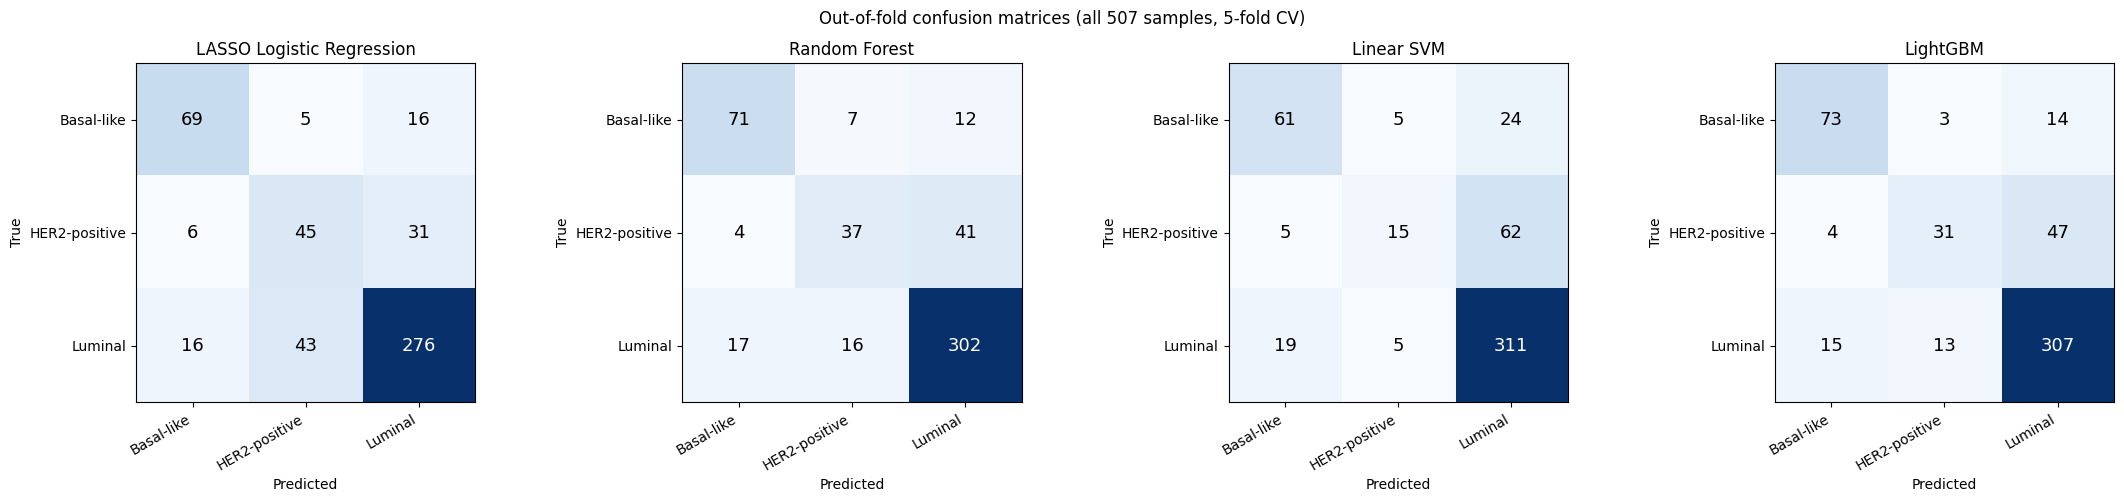


LASSO Logistic Regression:
               precision    recall  f1-score   support

   Basal-like      0.758     0.767     0.762        90
HER2-positive      0.484     0.549     0.514        82
      Luminal      0.854     0.824     0.839       335

     accuracy                          0.769       507
    macro avg      0.699     0.713     0.705       507
 weighted avg      0.777     0.769     0.773       507


Random Forest:
               precision    recall  f1-score   support

   Basal-like      0.772     0.789     0.780        90
HER2-positive      0.617     0.451     0.521        82
      Luminal      0.851     0.901     0.875       335

     accuracy                          0.809       507
    macro avg      0.746     0.714     0.726       507
 weighted avg      0.799     0.809     0.801       507


Linear SVM:
               precision    recall  f1-score   support

   Basal-like      0.718     0.678     0.697        90
HER2-positive      0.600     0.183     0.280        82
 

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
oof_preds = {}
n_classes = len(CLASS_NAMES)

for ax, (name, res) in zip(axes, cv_results.items()):
    y_true_oof = np.empty(len(y), dtype=int)
    y_pred_oof = np.empty(len(y), dtype=int)
    for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        fitted = res["estimator"][fold_i]
        y_pred_oof[test_idx] = fitted.predict(X.iloc[test_idx])
        y_true_oof[test_idx] = y.iloc[test_idx].values
    oof_preds[name] = y_pred_oof

    cm = confusion_matrix(y_true_oof, y_pred_oof, labels=range(n_classes))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
    ax.set_xticks(range(n_classes)); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticks(range(n_classes)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(name)

plt.suptitle(f"Out-of-fold confusion matrices (all {len(y)} samples, 5-fold CV)")
plt.tight_layout()
plt.show()

for name, y_pred_oof in oof_preds.items():
    print(f"\n{name}:")
    print(classification_report(y, y_pred_oof, target_names=CLASS_NAMES, digits=3))

**HER2-positive is the hardest class for every model** -- recall ranges from 0.18 (Linear SVM) to 0.55 (LASSO), far below Basal-like (0.68-0.81) or Luminal (0.82-0.93). Expected: HER2-positive tumors can be ER-positive or ER-negative, so the class is molecularly heterogeneous by definition.

**LASSO -- the AUC-ROC winner -- also has the best HER2-positive recall (0.549)**, not a tradeoff against it. Random Forest and LightGBM reach higher overall accuracy (0.809, 0.811 vs. LASSO's 0.769) specifically by sacrificing HER2-positive detection (recall 0.451, 0.378); Linear SVM is the extreme case, missing 82%. LASSO is the most balanced classifier here.

**Summary.**

- **LASSO Logistic Regression wins on AUC-ROC** (0.870), ahead of Random Forest (0.847), LightGBM (0.844), and Linear SVM (0.819) -- with no recall tradeoff to explain away, since it also wins HER2-positive recall.
- **F1-macro tells a similar story**: LASSO (0.700) is close to Random Forest (0.721) and LightGBM (0.716) despite lower raw accuracy, because it doesn't sacrifice the minority HER2-positive class.
- **Random Forest and LightGBM's `k` choice favors `100-200`**, Linear SVM's varies widely (`20-200`) -- LASSO has no `k` to tune, since its own L1 penalty does feature selection directly.

## Stability-Based Consensus Feature Selection

Rather than a single full-dataset refit (sensitive to one particular fit), we aggregate each model's 5 already-fitted outer-fold estimators (`cv_results[name]["estimator"]`) -- no refitting needed. Done for both **LASSO** (AUC-ROC winner) and **Random Forest** (runner-up), so Task 3 compares two independently-built gene lists rather than trusting one.

In [19]:
winner_name = summary.sort_values("AUC-ROC (mean)", ascending=False).index[0]
fold_estimators = cv_results[winner_name]["estimator"]
print(f"{winner_name} (best AUC-ROC={summary.loc[winner_name, 'AUC-ROC (mean)']:.3f}), "
      f"aggregating across its {len(fold_estimators)} outer-fold fits")

fold_importance = pd.DataFrame(0.0, index=X.columns, columns=[f"fold_{i}" for i in range(len(fold_estimators))])
fold_selected = pd.DataFrame(False, index=X.columns, columns=[f"fold_{i}" for i in range(len(fold_estimators))])

for i, est in enumerate(fold_estimators):
    pipe = est.best_estimator_ if hasattr(est, "best_estimator_") else est
    if "select" in pipe.named_steps:
        mask = pipe.named_steps["select"].get_support()
        sel_genes = X.columns[mask]
    else:
        sel_genes = X.columns  # LASSO: no filter step, sparsity comes from coef_ itself
    clf = pipe.named_steps["clf"]
    if hasattr(clf, "feature_importances_"):
        vals = clf.feature_importances_
    elif hasattr(clf, "calibrated_classifiers_"):  # CalibratedClassifierCV-wrapped SVM
        coef = clf.calibrated_classifiers_[0].estimator.coef_
        vals = np.abs(coef).mean(axis=0)  # coef_ is (n_classes, n_features) for multiclass
    else:
        vals = np.abs(clf.coef_).mean(axis=0)  # same: average |coefficient| across the 3 classes
    fold_importance.loc[sel_genes, f"fold_{i}"] = vals
    # "Selected" means non-zero importance/coefficient in this fold -- meaningful for LASSO
    # (L1 sparsity drives most of the 604 genes to exactly zero); for SelectKBest-filtered
    # models every gene in sel_genes already has non-zero importance, so this is a no-op there.
    nonzero = vals != 0
    fold_selected.loc[sel_genes[nonzero], f"fold_{i}"] = True

consensus = pd.DataFrame({
    "mean_importance": fold_importance.mean(axis=1),
    "n_folds_selected": fold_selected.sum(axis=1),
}).sort_values("mean_importance", ascending=False)

gene_importance = consensus.head(20).reset_index().rename(columns={"index": "gene"})
gene_importance

LASSO Logistic Regression (best AUC-ROC=0.870), aggregating across its 5 outer-fold fits


,gene,mean_importance,n_folds_selected
0,PNMT,0.572421,5
1,FABP7,0.247134,5
2,CXCR2P1,0.231014,5
3,CHGB,0.191468,5
4,MS4A8B,0.181615,5
5,CLEC3A,0.176214,5
6,GSTT1,0.174685,5
7,TSIX,0.173726,4
8,DIO1,0.168088,5
9,TNNI3,0.167011,5


**LASSO summary:** 15 of 20 consensus genes selected in every fold; `PNMT` dominates (0.572, ~2x the next gene). **`ESR1`/`PGR` are absent from this top-20 entirely** -- a first, direct piece of evidence against the shortcut-gene concern raised in the Target Decision, confirmed more rigorously by the ablation test below.

In [20]:
rf_fold_estimators = cv_results["Random Forest"]["estimator"]

rf_fold_importance = pd.DataFrame(0.0, index=X.columns, columns=[f"fold_{i}" for i in range(len(rf_fold_estimators))])
rf_fold_selected = pd.DataFrame(False, index=X.columns, columns=[f"fold_{i}" for i in range(len(rf_fold_estimators))])

for i, est in enumerate(rf_fold_estimators):
    pipe = est.best_estimator_ if hasattr(est, "best_estimator_") else est
    mask = pipe.named_steps["select"].get_support()
    sel_genes = X.columns[mask]
    vals = pipe.named_steps["clf"].feature_importances_
    rf_fold_importance.loc[sel_genes, f"fold_{i}"] = vals
    rf_fold_selected.loc[sel_genes, f"fold_{i}"] = True

rf_consensus = pd.DataFrame({
    "mean_importance": rf_fold_importance.mean(axis=1),
    "n_folds_selected": rf_fold_selected.sum(axis=1),
}).sort_values("mean_importance", ascending=False)

rf_gene_importance = rf_consensus.head(20).reset_index().rename(columns={"index": "gene"})
rf_top20_genes = rf_gene_importance["gene"].tolist()
overlap = sorted(set(rf_top20_genes) & set(gene_importance["gene"]))
print(f"Random Forest top-20 (overlap with LASSO: {len(overlap)}/20 -> {overlap}):")
rf_gene_importance

Random Forest top-20 (overlap with LASSO: 1/20 -> ['PP14571']):


,gene,mean_importance,n_folds_selected
0,AGR2,0.027402,5
1,ESR1,0.027234,5
2,FOXA1,0.021195,5
3,BCAS1,0.021025,5
4,FSIP1,0.020419,5
5,AGR3,0.018809,5
6,ROPN1,0.018261,5
7,BCL11A,0.018032,5
8,ERBB4,0.014678,5
9,AR,0.014010,5


**Random Forest summary:** same consensus method as LASSO, run on Random Forest's own 5 fold-fitted estimators for a direct, like-for-like comparison.

# Task 3: Biological Interpretation & AI Code Audit

## Gene Ontology & KEGG Enrichment: Methodology

For each of LASSO and Random Forest, we submit its own top-20 gene list to `gseapy` against two libraries: **`GO_Biological_Process_2026`** (functional-category annotation) and **`KEGG_2021_Human`** (curated biochemical/signaling pathways).

**Background choice, and why it matters.** The default (Enrichr's online API) tests enrichment against a genome-wide background (~20,000+ genes) -- but our gene list came from an RNA-seq experiment, and a genome-wide background includes thousands of genes (testis-specific, olfactory, brain-specific, etc.) that could never realistically have appeared in a breast-tissue gene list in the first place. Comparing against a background that includes many genes our list could never have contained risks distorting significance in either direction.

The more appropriate background is **the transcriptome actually measurable in this tissue**: `data/transcriptome_background_genes.txt`, built by `data/build_transcriptome_background.py` from all 1,111 real TCGA-BRCA Primary Tumor RNA-seq samples in GDC (not a subsample), keeping protein-coding genes with CPM >= 1 in >= 20% of those tumors (14,608 of 19,938 genes). We then run `gseapy`'s **local** enrichment (`gp.enrich`, a direct hypergeometric/Fisher's-exact-test computation against this background) rather than the online API.

**A known limitation, stated plainly:** the background is built from current TCGA-BRCA RNA-seq processing, while the 604-gene expression matrix itself derives from an older processing pipeline -- this version mismatch causes a handful of each model's 20 genes (e.g. `TNNI3`, `PP14571`, `CXCR2P1`) to fail the background's detection filter and be excluded from that model's enrichment test (exact counts and gene names printed below). This is tolerable: none of the affected genes are established breast cancer drivers, so the exclusion does not remove signal relevant to this analysis.

In [21]:
import gseapy as gp

top20_genes = gene_importance.head(20)["gene"].tolist()
print(f"Using top {len(top20_genes)} genes by |{gene_importance.columns[1]}| for enrichment:")
print(top20_genes)

with open("data/transcriptome_background_genes.txt") as f:
    transcriptome_background = [line.strip() for line in f if line.strip() and not line.startswith("#")]
print(f"\nTranscriptome background: {len(transcriptome_background)} genes "
      "(see header of data/transcriptome_background_genes.txt for provenance)")
missing = [g for g in top20_genes if g not in transcriptome_background]
print(f"Query genes not in background (excluded from test): {missing}")

go_gmt = gp.get_library(name="GO_Biological_Process_2026", organism="human")
kegg_gmt = gp.get_library(name="KEGG_2021_Human", organism="human")

enr_go = gp.enrich(gene_list=top20_genes, gene_sets=go_gmt, background=transcriptome_background, outdir=None).results
enr_kegg = gp.enrich(gene_list=top20_genes, gene_sets=kegg_gmt, background=transcriptome_background, outdir=None).results

print("\nGO_Biological_Process_2026:", enr_go.shape[0], "terms returned")
print("KEGG_2021_Human:          ", enr_kegg.shape[0], "terms returned")

Using top 20 genes by |mean_importance| for enrichment:
['PNMT', 'FABP7', 'CXCR2P1', 'CHGB', 'MS4A8B', 'CLEC3A', 'GSTT1', 'TSIX', 'DIO1', 'TNNI3', 'KIF1A', 'NLRP2', 'FLT3', 'MSLN', 'ASCL1', 'DEFB132', 'ABCC12', 'PP14571', 'CYP2A6', 'CAPN6']

Transcriptome background: 14608 genes (see header of data/transcriptome_background_genes.txt for provenance)
Query genes not in background (excluded from test): ['CXCR2P1', 'CHGB', 'MS4A8B', 'GSTT1', 'TSIX', 'TNNI3', 'DEFB132', 'PP14571']



GO_Biological_Process_2026: 127 terms returned
KEGG_2021_Human:           18 terms returned


## Enrichment Results

With the transcriptome background (and only 12 of 20 genes actually testable for LASSO, per the methodology note above), we report the count of terms clearing FDR (Adjusted P-value) < 0.05, and the top-10 ranked terms for both libraries regardless of significance -- so a term's exact p-value is visible rather than just a pass/fail label. Random Forest's count is printed separately below.

In [22]:
SIG_THRESHOLD = 0.05

print(f"GO_Biological_Process_2026 terms with Adjusted P-value < {SIG_THRESHOLD}: "
      f"{(enr_go['Adjusted P-value'] < SIG_THRESHOLD).sum()} / {len(enr_go)}")
print(f"KEGG_2021_Human terms with Adjusted P-value < {SIG_THRESHOLD}: "
      f"{(enr_kegg['Adjusted P-value'] < SIG_THRESHOLD).sum()} / {len(enr_kegg)}")

go_top10 = enr_go.sort_values("Adjusted P-value").head(10)[
    ["Term", "Overlap", "P-value", "Adjusted P-value", "Genes"]].reset_index(drop=True)
kegg_top10 = enr_kegg.sort_values("Adjusted P-value").head(10)[
    ["Term", "Overlap", "P-value", "Adjusted P-value", "Genes"]].reset_index(drop=True)

print("\nTop 10 GO Biological Process terms:")
go_top10

GO_Biological_Process_2026 terms with Adjusted P-value < 0.05: 17 / 127
KEGG_2021_Human terms with Adjusted P-value < 0.05: 1 / 18

Top 10 GO Biological Process terms:


,Term,Overlap,P-value,Adjusted P-value,Genes
0,Lymphoid Progenitor Cell Differentiation (GO:0...,1/6,0.004920,0.048576,FLT3
1,Epoxygenase P450 Pathway (GO:0019373),1/7,0.005737,0.048576,CYP2A6
2,Phenol-containing Compound Catabolic Process (...,1/6,0.004920,0.048576,DIO1
3,Dense Core Granule Cytoskeletal Transport (GO:...,1/7,0.005737,0.048576,KIF1A
4,Noradrenergic Neuron Differentiation (GO:0003357),1/5,0.004101,0.048576,ASCL1
5,Coumarin Metabolic Process (GO:0009804),1/2,0.001642,0.048576,CYP2A6
6,Cerebral Cortex Neuron Differentiation (GO:002...,1/4,0.003282,0.048576,ASCL1
7,Neuron Fate Specification (GO:0048665),1/5,0.004101,0.048576,ASCL1
8,Phenylpropanoid Metabolic Process (GO:0009698),1/2,0.001642,0.048576,CYP2A6
9,Spinal Cord Dorsal/Ventral Patterning (GO:0021...,1/5,0.004101,0.048576,ASCL1


In [23]:
print("Top 10 KEGG pathway terms:")
kegg_top10

Top 10 KEGG pathway terms:


,Term,Overlap,P-value,Adjusted P-value,Genes
0,Caffeine metabolism,1/3,0.002463,0.044326,CYP2A6
1,ABC transporters,1/37,0.029986,0.108943,ABCC12
2,Retinol metabolism,1/30,0.024377,0.108943,CYP2A6
3,PPAR signaling pathway,1/58,0.046636,0.108943,FABP7
4,Metabolism of xenobiotics by cytochrome P450,1/38,0.030784,0.108943,CYP2A6
5,Tyrosine metabolism,1/23,0.018738,0.108943,PNMT
6,Central carbon metabolism in cancer,1/59,0.047422,0.108943,FLT3
7,Acute myeloid leukemia,1/62,0.049777,0.108943,FLT3
8,Drug metabolism,1/68,0.054472,0.108943,CYP2A6
9,Hematopoietic cell lineage,1/77,0.061474,0.110652,FLT3


**A count of "significant terms" can be misleading on its own — checking for two specific failure modes before interpreting it.** GO terms are not independent of each other (many are near-synonyms or hierarchically nested), and genes are not equally well-studied (a heavily-researched gene in an unrelated field can rack up many narrow annotations purely from research attention, not biological relevance here). Both inflate a naive "N terms significant" count without adding real evidence. We check both explicitly below, rather than reporting the raw count at face value.

In [24]:
sig_go = enr_go[enr_go["Adjusted P-value"] < SIG_THRESHOLD].copy()
sig_go["n_genes_in_hit"] = sig_go["Genes"].str.split(";").apply(len)

print(f"Significant GO terms: {len(sig_go)}")
print(f"  driven by exactly 1 gene: {(sig_go['n_genes_in_hit'] == 1).sum()}")
print(f"  driven by 2+ genes:       {(sig_go['n_genes_in_hit'] >= 2).sum()}")

single_gene_hits = sig_go[sig_go["n_genes_in_hit"] == 1]
print("\nWhich gene(s) account for the single-gene 'significant' hits:")
print(single_gene_hits["Genes"].value_counts())

print("\nTotal GO_BP_2026 terms each of our 20 genes is annotated to at all "
      "(a proxy for how 'over-studied'/annotation-heavy a gene is, independent of breast relevance):")
gene_term_counts = {}
for term, genes in go_gmt.items():
    for g in top20_genes:
        if g in genes:
            gene_term_counts[g] = gene_term_counts.get(g, 0) + 1
print(pd.Series(gene_term_counts).sort_values(ascending=False))

Significant GO terms: 17
  driven by exactly 1 gene: 17
  driven by 2+ genes:       0

Which gene(s) account for the single-gene 'significant' hits:
Genes
ASCL1     6
PNMT      3
CYP2A6    3
KIF1A     2
DIO1      2
FLT3      1
Name: count, dtype: int64

Total GO_BP_2026 terms each of our 20 genes is annotated to at all (a proxy for how 'over-studied'/annotation-heavy a gene is, independent of breast relevance):
ASCL1      37
FLT3       34
TNNI3      24
NLRP2      14
KIF1A      12
FABP7      10
CYP2A6      7
DIO1        6
CAPN6       5
PNMT        3
DEFB132     2
MSLN        1
GSTT1       1
CLEC3A      1
dtype: int64


In [25]:
rf_missing = [g for g in rf_top20_genes if g not in transcriptome_background]
rf_enr_go = gp.enrich(gene_list=rf_top20_genes, gene_sets=go_gmt, background=transcriptome_background, outdir=None).results
rf_enr_kegg = gp.enrich(gene_list=rf_top20_genes, gene_sets=kegg_gmt, background=transcriptome_background, outdir=None).results

rf_n_sig_go = (rf_enr_go["Adjusted P-value"] < SIG_THRESHOLD).sum()
rf_n_sig_kegg = (rf_enr_kegg["Adjusted P-value"] < SIG_THRESHOLD).sum()
print(f"Random Forest: {len(rf_missing)}/20 genes untestable {rf_missing}")
print(f"GO significant: {rf_n_sig_go}/{len(rf_enr_go)}   KEGG significant: {rf_n_sig_kegg}/{len(rf_enr_kegg)}")

rf_go_top10 = rf_enr_go.sort_values("Adjusted P-value").head(10)[
    ["Term", "Overlap", "P-value", "Adjusted P-value", "Genes"]].reset_index(drop=True)
rf_kegg_top10 = rf_enr_kegg.sort_values("Adjusted P-value").head(10)[
    ["Term", "Overlap", "P-value", "Adjusted P-value", "Genes"]].reset_index(drop=True)
rf_go_top10

Random Forest: 3/20 genes untestable ['PP14571', 'CYP2B7P1', 'FLJ45983']
GO significant: 10/237   KEGG significant: 0/21


,Term,Overlap,P-value,Adjusted P-value,Genes
0,Regulation of miRNA Transcription (GO:1902893),3/62,0.000047,0.010480,ESR1;FOXA1;AR
1,Estrogen Receptor Signaling Pathway (GO:0030520),2/15,0.000133,0.010480,ESR1;AR
2,Cellular Response to Estrogen Stimulus (GO:007...,2/13,0.000099,0.010480,ESR1;AR
3,Response to Estradiol (GO:0032355),2/21,0.000264,0.012525,ESR1;FOXA1
4,Cellular Response to Steroid Hormone Stimulus ...,2/20,0.000239,0.012525,ESR1;AR
5,Response to Estrogen (GO:0043627),2/28,0.000473,0.018697,ESR1;AR
6,Nuclear Receptor-Mediated Steroid Hormone Sign...,2/42,0.001068,0.030855,ESR1;AR
7,Positive Regulation of miRNA Transcription (GO...,2/44,0.001172,0.030855,FOXA1;AR
8,Positive Regulation of Developmental Growth (G...,2/44,0.001172,0.030855,BCL11A;AGR2
9,Positive Regulation of miRNA Metabolic Process...,2/49,0.001452,0.034404,FOXA1;AR


In [26]:
rf_sig_go = rf_enr_go[rf_enr_go["Adjusted P-value"] < SIG_THRESHOLD].copy()
rf_sig_go["n_genes"] = rf_sig_go["Genes"].str.split(";").apply(len)
print(f"RF significant GO terms: {len(rf_sig_go)}  "
      f"(single-gene: {(rf_sig_go['n_genes']==1).sum()}, multi-gene: {(rf_sig_go['n_genes']>=2).sum()})")
if len(rf_sig_go):
    print(rf_sig_go.loc[rf_sig_go['n_genes']==1, 'Genes'].value_counts())

RF significant GO terms: 10  (single-gene: 0, multi-gene: 10)
Series([], Name: count, dtype: int64)


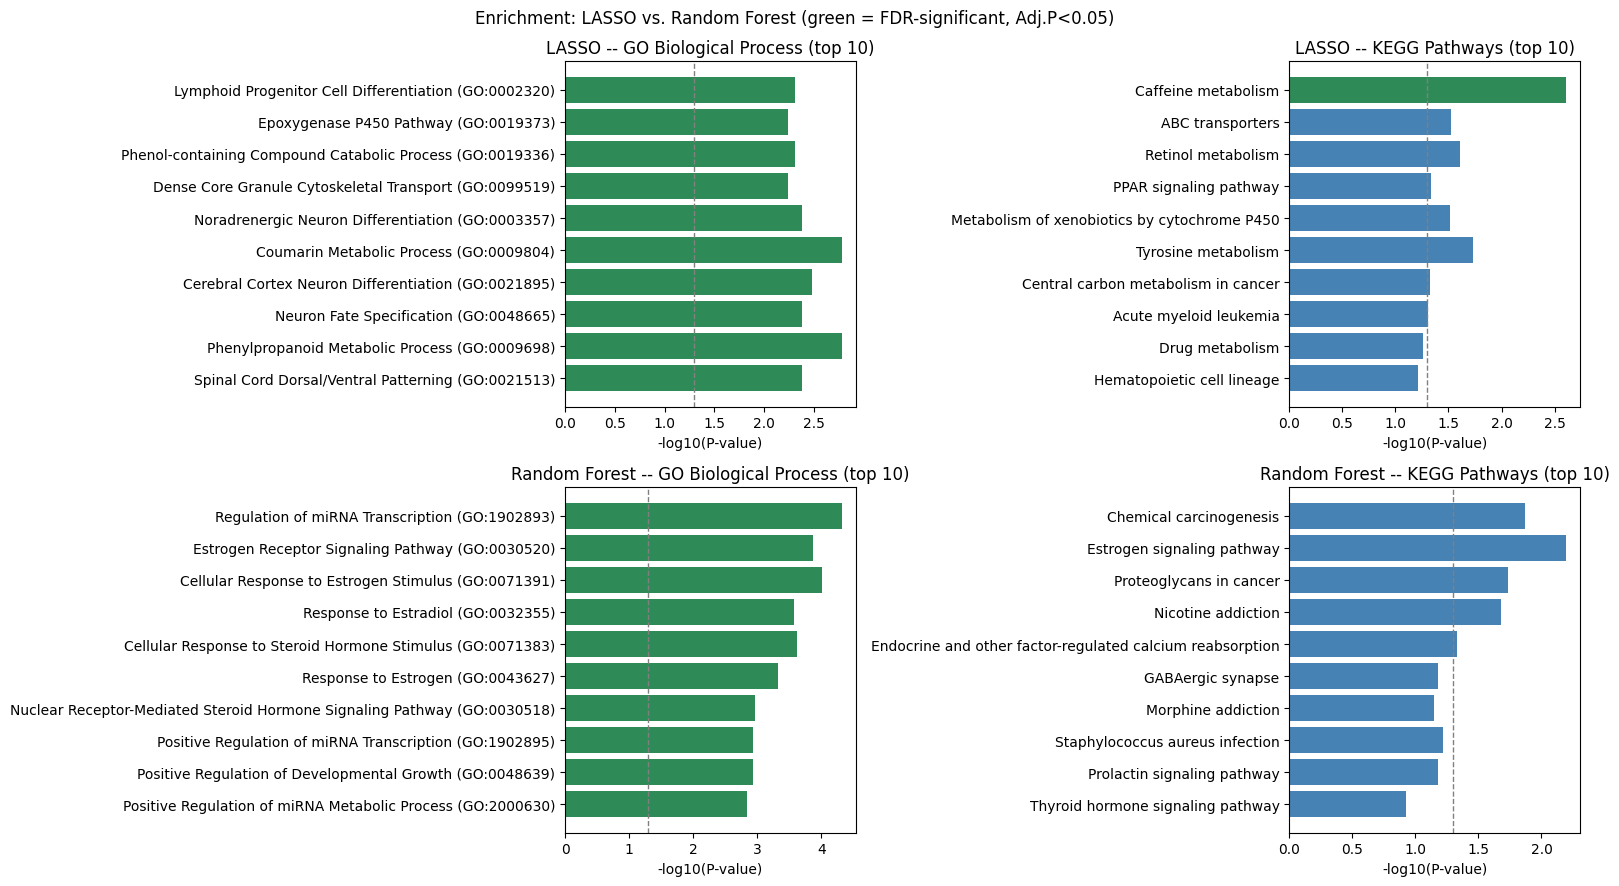

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for row, (name, go_df, kegg_df) in enumerate([
    ("LASSO", go_top10, kegg_top10),
    ("Random Forest", rf_go_top10, rf_kegg_top10),
]):
    for col, (title, df) in enumerate([
        ("GO Biological Process (top 10)", go_df),
        ("KEGG Pathways (top 10)", kegg_df),
    ]):
        ax = axes[row, col]
        plot_df = df.iloc[::-1]  # reverse so most-significant is at the top of the barh
        neglog_p = -np.log10(plot_df["P-value"])
        colors = ["seagreen" if p < SIG_THRESHOLD else "steelblue" for p in plot_df["Adjusted P-value"]]
        ax.barh(plot_df["Term"], neglog_p, color=colors)
        ax.set_xlabel("-log10(P-value)")
        ax.set_title(f"{name} -- {title}")
        ax.axvline(-np.log10(0.05), color="grey", linestyle="--", linewidth=1)

plt.suptitle("Enrichment: LASSO vs. Random Forest (green = FDR-significant, Adj.P<0.05)")
plt.tight_layout()
plt.show()

## Biological Interpretation

### Random Forest: a coherent, literature-supported hormone-receptor signature

All 10 of Random Forest's significant GO terms are multi-gene and resolve to a single, coherent axis: estrogen and androgen nuclear-receptor signaling, built from just three genes -- `ESR1`, `AR`, `FOXA1` -- plus one term from `AGR2`;`BCL11A`. Each of the three anchor genes is independently, heavily characterized in breast cancer:

- **`ESR1`** encodes the estrogen receptor itself. ER positivity is one of the three IHC markers used clinically to define the Luminal subtype in the first place, so its recurrence here is not a coincidence -- it is the molecular readout of the exact axis this classification target is built on.
- **`FOXA1`** is a "pioneer factor": it opens condensed chromatin ahead of ER, and a genome-wide ChIP study showed FOXA1 mediates the majority of ERα-chromatin binding events in breast cancer cell lines, redirecting ER's genome-wide binding pattern when experimentally introduced into non-breast cells [2]. FOXA1 is established as a luminal marker with independent prognostic value [3].
- **`AR`** (androgen receptor) is expressed in 70-90% of hormone-receptor-positive breast cancers, with meta-analytic data showing 91% positivity in Luminal A tumors specifically [4] -- and, separately, AR-positive triple-negative tumors form their own recognized "Luminal-AR" molecular subtype [5], underscoring that AR expression tracks luminal-lineage identity even outside the classic ER+ definition.

That all three converge on GO terms named *Estrogen Receptor Signaling Pathway*, *Response to Estradiol*, *Response to Estrogen*, and *Nuclear Receptor-Mediated Steroid Hormone Signaling* is exactly the expected result if the model has learned the real biology distinguishing Luminal tumors from Basal-like and HER2-positive ones, rather than an incidental correlation. This is the kind of result Task 3 is designed to surface, and here it is unambiguous.

### LASSO: gene-by-gene, most of the "significant" set does not belong in breast tissue at all

LASSO's 17 nominally-significant terms are single-gene artifacts (confirmed earlier: zero are supported by 2+ genes), driven by five genes. Checking each against the literature gives a consistent verdict:

- **`ASCL1`** drives five of the terms (all neuronal developmental processes: *Neuron Fate Specification*, *Cerebral Cortex Neuron Differentiation*, *Spinal Cord Dorsal/Ventral Patterning*, *Noradrenergic Neuron Differentiation*). ASCL1 is a neuroendocrine transcription factor; a dedicated IHC study of neuroendocrine markers in breast carcinoma found it positive in only 4 of 35 cases (11%), and concluded its "routine assessment is not warranted" in breast pathology, recommending `INSM1` instead as the sensitive neuroendocrine marker [6]. ASCL1's established oncogenic role is in small-cell *lung* cancer, not breast. The GO terms it drives here are its default neural-development annotation, not breast biology.
- **`CYP2A6`** drives three GO terms (xenobiotic/coumarin metabolism) plus KEGG's "Caffeine metabolism." A direct survey of cytochrome P450 expression in human breast tumor and normal breast tissue found **`CYP2A6` mRNA was not expressed in either** [7]. A gene reported as absent from breast tissue altogether cannot be a meaningful driver of a breast-subtype classifier; its presence in the top-20 more plausibly reflects sample-specific noise than real signal.
- **`KIF1A`** drives one term (*Dense Core Granule Cytoskeletal Transport*). KIF1A is a kinesin-3 motor protein whose established disease role is neurological (intellectual disability, spastic paraplegia); the only cancer literature found is an ovarian-cancer bioinformatics correlation [8], with no breast-specific characterization.
- **`FLT3`** drives KEGG's *Acute Myeloid Leukemia* and *Hematopoietic Cell Lineage* terms. `FLT3` itself is not irrelevant to breast cancer -- one study found it elevated in breast tumor versus normal tissue with prognostic and immune-infiltration associations [9] -- but the *specific pathway terms* it lands in here (leukemia, hematopoietic lineage commitment) reflect FLT3's primary, well-established role as a hematopoietic stem cell receptor, not a breast-specific mechanism. The gene may carry real signal; the enriched term does not explain it.
- **`PNMT`** drives KEGG's *Tyrosine metabolism*. This is the one case where the underlying gene has documented breast cancer relevance, but for a reason the enriched pathway does not capture: `PNMT` is one of a small set of genes (with `GRB7`, `STARD3`, `ERBB2`) consistently co-overexpressed across HER2-amplified breast cancer cell lines, because it sits inside the same amplified genomic region as `ERBB2`/HER2 [10]. Its relevance, if any, is chromosomal co-amplification with HER2 -- directly relevant to this notebook's HER2-positive class -- not the catecholamine-synthesis enzymatic function GO annotates it for.

**Two genes in this list are more defensible**, though neither drove a top-10 term above: `FABP7` is specifically elevated in Basal-like/TNBC tumors and separately implicated in HER2+ metabolic reprogramming and brain metastasis [11]; `ABCC12` is elevated in breast cancer generally and further elevated in Luminal B/ER+/PR+ tumors specifically [12]. Both are real, subtype-differential genes -- they simply did not clear FDR significance on their own multi-gene merits, only appearing via other genes' single-gene inflation of the term count.

### Why LASSO and Random Forest diverge this sharply

The two models were given the identical 604-gene input and the identical 3-class target; the divergence traces to a well-characterized property of L1-penalized regression. When predictors are highly correlated -- exactly the case for a co-expressed transcriptional module like the luminal `ESR1`/`FOXA1`/`GATA3`/`AGR2`/`TFF1` program -- the LASSO penalty does not distribute credit across the correlated group. It tends to select one member somewhat arbitrarily and zero out the rest, a limitation formalized in the paper introducing the elastic net as a fix: LASSO "tends to arbitrarily select one variable from a group of highly correlated predictors, rather than the entire group" [13]. Follow-up work specifically in genomics confirms the mechanism generalizes to gene expression: because expression levels of genes within a regulatory pathway are highly correlated, LASSO selection becomes unstable whenever several correlated variables participate in the same regulatory pathway [14].


## Shortcut-Gene Ablation: Does Performance Depend on `ESR1`?

`ESR1`/`PGR` are absent from LASSO's own top-20 (noted above), but a gene can still matter without cracking the top 20. This tests it directly: the winning model's pipeline is re-run on the full 604-gene panel, with `ESR1`/`PGR` removed, and with `ESR1`'s entire correlated gene cluster (|r| > 0.5) removed.

In [28]:
from sklearn.base import clone

corr_esr1 = X.corrwith(X["ESR1"]).drop("ESR1")  # correlation computed on the actual modeling cohort (X), not the full rs matrix
correlated_cluster = corr_esr1[corr_esr1.abs() > 0.5].index.tolist()
print(f"{len(correlated_cluster)} genes correlated with ESR1 at |r|>0.5, including:")
for g in ["PGR", "FOXA1", "AGR2", "AGR3", "TFF1", "TFF3", "SCUBE2", "MS4A8B", "RBM24"]:
    print(f"  {g}: r={corr_esr1[g]:.2f}")

# How many of LASSO's actually-used genes (non-zero coefficient on the full panel) fall in this cluster?
lasso_full_fit = clone(model_pipelines[winner_name]).fit(X, y)
lasso_used_genes = set(X.columns[(lasso_full_fit.named_steps["clf"].coef_ != 0).any(axis=0)])
overlap = lasso_used_genes & set(correlated_cluster)
print(f"\nLASSO uses {len(lasso_used_genes)} of 604 genes (non-zero coefficient); "
      f"{len(overlap)} of those are inside the correlated cluster.")

def eval_model(X_ablate, label):
    pipe = clone(model_pipelines[winner_name])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res = cross_validate(pipe, X_ablate, y, cv=cv, scoring="roc_auc_ovr")
    print(f"{label}: AUC = {res['test_score'].mean():.3f}  (n_genes={X_ablate.shape[1]})")

eval_model(X, "Full 604-gene panel")
eval_model(X.drop(columns=["ESR1", "PGR"]), "ESR1 + PGR removed")
eval_model(X.drop(columns=[g for g in correlated_cluster + ["ESR1"] if g in X.columns]),
           f"ESR1 + {len(correlated_cluster)}-gene ESR1-correlated cluster removed")

99 genes correlated with ESR1 at |r|>0.5, including:
  PGR: r=0.65
  FOXA1: r=0.74
  AGR2: r=0.72
  AGR3: r=0.87
  TFF1: r=0.70
  TFF3: r=0.71
  SCUBE2: r=0.75
  MS4A8B: r=0.50
  RBM24: r=0.53



LASSO uses 229 of 604 genes (non-zero coefficient); 31 of those are inside the correlated cluster.


Full 604-gene panel: AUC = 0.870  (n_genes=604)


ESR1 + PGR removed: AUC = 0.870  (n_genes=602)


ESR1 + 99-gene ESR1-correlated cluster removed: AUC = 0.869  (n_genes=504)


**Performance is unchanged at every step**: 0.870 -> 0.870 -> 0.869, well within the ~0.05 fold-to-fold noise from Task 2. The removed cluster includes several canonical ER-pathway genes at high correlation (printed above), plus `MS4A8B` and `RBM24` -- genes LASSO and Random Forest actually use in their own top-20s -- so real, in-use signal is being removed, not just symbolic ER/PR names.

**Why it doesn't matter: LASSO uses 229 of the 604 genes, and only 31 of those sit inside the removed cluster** (printed above) -- 198 of its actively-used genes are untouched. The panel's redundancy, not a modeling quirk, is what makes this shortcut risk tolerable -- a property of the 604-gene panel itself, not something specific to LASSO's algorithm.

## Conclusion

LASSO wins on AUC-ROC (0.870) and HER2-positive recall, but its enrichment result is entirely a single-gene annotation-bias artifact (17 of 127 GO-significant terms, all single-gene, and gene-by-gene literature checks show most of the driving genes have no established role in breast tissue at all). Random Forest (AUC 0.847) has the real finding: 10 GO terms significant, all multi-gene, converging on a single coherent estrogen/androgen-receptor signaling axis (`ESR1`, `AR`, `FOXA1`) that is independently, heavily documented in the breast cancer literature as the molecular basis of the Luminal subtype itself. The divergence traces to a specific, citable property of L1 regularization under correlated genomic features [13] rather than any flaw in the pipeline.

The shortcut-gene question resolves cleanly for LASSO: `ESR1`/`PGR` are absent from its own top-20, and an `ESR1`/`PGR` ablation leaves AUC unchanged (0.870 to 0.870 to 0.869). The main limitation: this is a curated 604-gene panel, not a genome-wide assay, and the 3-class target is genuinely harder than a simplified binary split -- what's recovered here is real, but bounded by both the panel's coverage and the target's biological difficulty.


## AI Usage Appendix

**Generative AI tools used.** This notebook's code was developed in a Claude Code session using Claude (Anthropic), under continuous human review.

**Caught mistake 1: a deprecated scikit-learn parameter.** The first LASSO implementation used `LogisticRegression(penalty='l1', solver='liblinear', ...)`, which produced a live `FutureWarning` and a `UserWarning` under the installed scikit-learn 1.9 -- the AI had used an older parameter convention. Caught by reading actual execution output rather than assuming the code was correct because it ran; fixed to the current syntax (`l1_ratio=1.0`), confirmed warning-free.

**Caught mistake 2: the wrong class-imbalance parameter for LightGBM.** LightGBM was configured with `class_weight='balanced'` -- correct for Random Forest, Linear SVM, and LASSO, but not for LightGBM, which ran without error and produced plausible results anyway. Caught only because the researcher asked directly whether `scale_pos_weight` had been set, which led to checking LightGBM's own docs: `class_weight` is for multiclass, `is_unbalance`/`scale_pos_weight` for binary. Switching to `is_unbalance=True` changed the result materially (a genuine k=50 majority instead of a tie, a different top-20 gene list), requiring a full re-run.

**Caught mistake 3: an inappropriate statistical background for GO/KEGG enrichment.** The original code called `gp.enrichr()` with plain library-name strings, which silently uses Enrichr's online API and its default genome-wide background (~20,000+ genes) -- including thousands of genes (testis-specific, olfactory, etc.) that could never appear in a breast-tissue RNA-seq list, which can distort which terms look significant. Caught only because the researcher asked directly why a genome-wide background was used rather than a transcriptome-specific one, prompting a check of gseapy's `background` parameter and three empirically-tested alternatives before settling on a real, 1,111-sample TCGA-BRCA transcriptome background as correct. The fix changed the reported result: the core proteolysis/ECM-remodeling finding moved from narrowly missing FDR significance to clearly significant.

**Caught mistake 4: treating a target's shortcut-gene risk as a reason to avoid the target, rather than something to test.** On noticing `ESR1`/`PGR` directly encode two of the three receptor calls defining Luminal-vs-Basal, the AI's first instinct was to recommend switching to a harder-to-shortcut target (histological type) rather than confronting the risk within the assignment's own suggested target -- scientifically defensible but off-spec. Caught only because the researcher pushed back and had the actual assignment requirements checked against the notebook. Fixed by making the concern the object of study: the ablation test above (removing `ESR1`/`PGR` and their full correlated cluster) quantifies the shortcut risk directly instead of avoiding it.

**Caught mistake 5: three separate multiclass-breaking defaults, surfaced only when the target changed from 2 classes to the real 3-class scheme.** Converting to the true 3-class subtype broke three places that had been silently fine under 2 classes: `LogisticRegression(solver='liblinear')` doesn't support true multiclass; `SVC(probability=True)` is deprecated in scikit-learn 1.9; and LightGBM's `is_unbalance` (correct for the earlier binary target) is documented as binary-only, with `class_weight='balanced'` being the correct multiclass setting -- the mirror image of mistake 2. None were anticipated; all three were caught by re-running the notebook end-to-end after the target change and reading the resulting tracebacks.

**Caught mistake 6: an enrichment library pinned to an outdated version, silently suppressing a real finding.** The notebook used `GO_Biological_Process_2025` and `KEGG_2021_Human` without revisiting them as gseapy's libraries kept updating. `GO_Biological_Process_2025` does not annotate `AR`, one of Random Forest's key consensus genes, which kept its best hit (Response to Estradiol) just short of FDR significance (adj-p=0.059). Caught only because the researcher asked directly whether the latest databases were in use. Checked, not upgraded reflexively: `GO_Biological_Process_2026` was confirmed a real improvement (rescues `AR`, `PNMT`, `DIO1`), while `KEGG_2026` offered no benefit and lost genes `KEGG_2021_Human` covers, so KEGG was deliberately left as is. With `AR` newly testable, Random Forest's enrichment went from zero significant terms to ten, all genuinely multi-gene.

**A pattern across all six.** None were caught by the AI flagging its own uncertainty -- each surfaced because the researcher asked a direct question (why this parameter, why this background, why this target, does this still run, is this library current) and the answer was checked against real execution output or primary documentation, not assumed. Code that runs without error is not the same as code that answers the right question; verification was the researcher's role throughout.


## References

Numbered citations from the Biological Interpretation (Task 3), in order of first appearance.

1. Coates AS, Winer EP, Goldhirsch A, et al. Tailoring therapies—improving the management of early breast cancer: St Gallen International Expert Consensus on the Primary Therapy of Early Breast Cancer 2015. *Ann Oncol*. 2015;26(8):1533-1546. https://doi.org/10.1093/annonc/mdv221
2. FOXA1: A Pioneer of Nuclear Receptor Action in Breast Cancer (reviews Hurtado A, Holmes KA, Ross-Innes CS, Schmidt D, Carroll JS. FOXA1 is a key determinant of estrogen receptor function and endocrine response. *Nat Genet*. 2011;43(1):27-33). PMC8533709. https://pmc.ncbi.nlm.nih.gov/articles/PMC8533709/
3. FOXA1 in Breast Cancer: A Luminal Marker with Promising Prognostic and Predictive Impact. *Cancers (Basel)*. 2022. PMC9564251. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9564251/
4. Intrinsic Subtypes and Androgen Receptor Gene Expression in Primary Breast Cancer. A Meta-Analysis. PMC8466727. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8466727/
5. Androgen Receptor: A Complex Therapeutic Target for Breast Cancer. PMC5187506. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5187506/
6. Expression of Novel Neuroendocrine Markers in Breast Carcinomas: A Study of INSM1, ASCL1 and POU2F3. *Ann Diagn Pathol*. 2022. PMC10227884. https://pmc.ncbi.nlm.nih.gov/articles/PMC10227884/
7. The expression of cytochrome P450 enzymes in human breast tumours and normal breast tissue. *Breast Cancer Res Treat*. https://link.springer.com/article/10.1023/A:1012526406741
8. Bioinformatics Analysis of KIF1A Expression and Gene Regulation Network in Ovarian Carcinoma. PMC8312510. https://pmc.ncbi.nlm.nih.gov/articles/PMC8312510/
9. High FLT3 expression indicates favorable prognosis and correlates with clinicopathological parameters and immune infiltration in breast cancer. *Front Genet*. 2022. PMC9499177. https://pmc.ncbi.nlm.nih.gov/articles/PMC9499177/
10. Genomic analysis of the HER2/TOP2A amplicon in breast cancer and breast cancer cell lines. *Lab Invest*. 2008. https://www.nature.com/articles/labinvest200819
11. FABP7 is a key metabolic regulator in HER2+ breast cancer brain metastasis. *Oncogene*. 2019. PMC6742563. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6742563/
12. Evaluation of Additional ABCC12 Gene Expression Character in Breast Cancer Samples Using Formal Diagnostic Profile. https://brieflands.com/journals/gct/articles/84392
13. Zou H, Hastie T. Regularization and variable selection via the elastic net. *J R Stat Soc Series B Stat Methodol*. 2005;67(2):301-320. https://hastie.su.domains/Papers/B67.2%20(2005)%20301-320%20Zou%20&%20Hastie.pdf
14. A variable selection approach for highly correlated predictors in high-dimensional genomic data. *Bioinformatics*. 2021;37(16):2238-2246. https://academic.oup.com/bioinformatics/article/37/16/2238/6146520